In [1]:
import os
import sys
import datetime
import pandas as pd
import pytrends
from pytrends.request import TrendReq
print("Dattime= {0}".format(datetime.datetime.now()))

Dattime= 2020-10-20 08:29:41.581303


In [2]:
pytrends = TrendReq(hl='en-US', tz=360)
kw_list = [  "work from home",  "unemployment", "indeed jobs", "work"]
# "unemployment", "job" " ui online"
#,'hire', "Jobs", "vacancy", "employment", "unemployment", "benefits"] "njuifile"
nweeks = 200
end_date = datetime.date.today().strftime("%Y-%m-%d")
start_date = (datetime.date.today() - datetime.timedelta(weeks=nweeks)).strftime("%Y-%m-%d")
timeframe = start_date+ " " + end_date  
print(timeframe)
geo = 'US'
pytrends.build_payload(kw_list, cat=60, timeframe=timeframe, geo=geo, gprop='')

2016-12-20 2020-10-20


In [3]:
df = pytrends.interest_over_time()


<AxesSubplot:xlabel='date'>

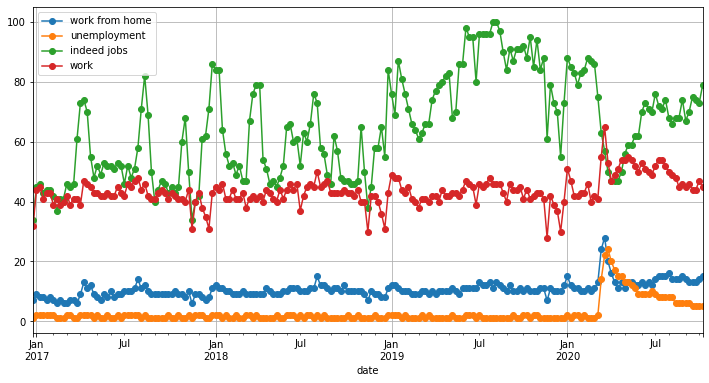

In [4]:
df.plot(figsize=[12,6], grid=True, marker='o')

In [5]:
pytrends.suggestions("job")

[{'mid': '/m/04115t2', 'title': 'Job', 'type': 'Topic'},
 {'mid': '/m/07s_c', 'title': 'Unemployment', 'type': 'Topic'},
 {'mid': '/m/01rbb', 'title': 'Crime', 'type': 'Topic'},
 {'mid': '/m/019323', 'title': 'Duty', 'type': 'Topic'},
 {'mid': '/g/1211q_qf', 'title': 'job', 'type': 'Topic'}]

In [6]:
dir(pytrends)
related = pytrends.related_queries()
related.keys()

dict_keys(['work from home', 'unemployment', 'indeed jobs', 'work'])

In [15]:
from collections import deque
import time

def build_payload(pytrends, kw, nweeks=100, geo='US', cat=60):
    end_date = datetime.date.today()
    start_date = datetime.date.today() - datetime.timedelta(weeks=nweeks)
    timeframe = start_date.strftime("%Y-%m-%d") + " " + end_date.strftime("%Y-%m-%d")  
    pytrends.build_payload([kw], cat=cat, timeframe=timeframe, geo=geo, gprop='')    
    return pytrends

sleeptime = 0.25
verbosity=1
max_keywords = 100

keywords2try = deque()
keywords = deque()
keyword_set = set()

# seed the queue with a few terms
keywords2try.appendleft(("jobs", 'root', 101))
keywords2try.appendleft(("unemployment", 'root', 101))

while len(keywords2try) > 0:
    if len(keywords) > max_keywords:
        break
    kw, parent, score = keywords2try.pop()
    if kw in keyword_set:
        if verbosity > 1:
            print("{0} already in set".format(kw))
        continue
    if verbosity > 0:
        print("Adding kw: {0}".format(kw))        
    keywords.appendleft((kw, parent, score))
    pytrends = TrendReq(hl='en-US', tz=360)    
    pytrends = build_payload(pytrends, kw)
    time.sleep(.5)
    related = pytrends.related_queries()
    if not related:
        if verbosity > 1:
            print("\t No related")
        continue
    if 'top' not in related[kw].keys():
        if verbosity > 1:
            print("\tNo top")
        continue
    df = related[kw]['top']
    if df is None:
        if verbosity > 1:
            print("\ttop is empty")
        continue
    for tup in df.itertuples():
        if tup.value > 95 and tup.query not in keyword_set:
            print("pushing {0}".format(tup.query))
            keywords2try.appendleft((tup.query, kw, tup.value))
print("done")
kw_df = pd.DataFrame(data=list(keywords), columns=['kwyword', 'parent', 'score']).sort_values(by="score", ascending=False)
kw_df.head()

Adding kw: jobs
pushing jobs near
Adding kw: unemployment
pushing unemployment jobs
Adding kw: jobs near
pushing jobs near me
Adding kw: unemployment jobs
pushing unemployment rate
Adding kw: jobs near me
pushing jobs hiring near me
Adding kw: unemployment rate
Adding kw: jobs hiring near me
pushing jobs near me hiring part time
pushing jobs hiring near me part time
Adding kw: jobs near me hiring part time
pushing job hiring near me
Adding kw: jobs hiring near me part time
pushing job hiring near me
Adding kw: job hiring near me
pushing jobs near me hiring
Adding kw: job hiring near me
pushing jobs near me hiring
Adding kw: jobs near me hiring
pushing jobs near me hiring part time
pushing jobs hiring near me part time
Adding kw: jobs near me hiring
pushing jobs near me hiring part time
pushing jobs hiring near me part time
Adding kw: jobs near me hiring part time
pushing job hiring near me
Adding kw: jobs hiring near me part time
pushing job hiring near me
Adding kw: jobs near me hirin

,kwyword,parent,score
100,jobs,root,101
99,unemployment,root,101
55,jobs near me hiring,job hiring near me,100
63,job hiring near me,jobs near me hiring part time,100
62,job hiring near me,jobs hiring near me part time,100


,kwyword,parent,score
3,unemployment,root,101
4,jobs,root,101
0,jobs near me,jobs near,100
1,unemployment jobs,unemployment,100
2,jobs near,jobs,100


In [17]:
kw_df


,kwyword,parent,score
100,jobs,root,101
99,unemployment,root,101
55,jobs near me hiring,job hiring near me,100
63,job hiring near me,jobs near me hiring part time,100
62,job hiring near me,jobs hiring near me part time,100
...,...,...,...
40,jobs hiring near me part time,jobs near me hiring,97
38,jobs hiring near me part time,jobs near me hiring,97
36,jobs hiring near me part time,jobs near me hiring,97
2,jobs hiring near me part time,jobs near me hiring,97
